In [21]:
# 1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Plot style settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style="whitegrid")

In [23]:
# 2. LOAD THE DATASET

df = pd.read_csv("dataofsuperstore", encoding='latin-1')  # Use your file name
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
# 3. DATA CLEANING

print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [25]:
# Remove duplicates
df = df.drop_duplicates()

In [26]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [27]:
# Remove rows with invalid sales/profit if needed
df = df[df["Sales"] > 0]

In [28]:
print("\nData Types After Cleaning:\n")
print(df.info())



Data Types After Cleaning:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object      

In [29]:
# 4. DATASET OVERVIEW
print("\nDataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)


Dataset Shape: (9994, 21)

Column Names:
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [55]:
print("\nGeneral Description of Numerical Data:\n")
print(df.describe())


General Description of Numerical Data:

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit        Month  
count  9994.000000  9994.000000  
mean     28.656896     7.809686  
std     234.260108     3.284654  
min   -6599.978000     1.000000  
25%       1.728750     5.000000  
50%       8.666500     9.000000  
75%      29.364000    11.000000  
ma

In [31]:
print("\nGeneral Description of Categorical Data:\n")
print(df.describe(include="object"))


General Description of Categorical Data:

              Order ID       Ship Mode Customer ID  Customer Name   Segment  \
count             9994            9994        9994           9994      9994   
unique            5009               4         793            793         3   
top     CA-2017-100111  Standard Class    WB-21850  William Brown  Consumer   
freq                14            5968          37             37      5191   

              Country           City       State Region       Product ID  \
count            9994           9994        9994   9994             9994   
unique              1            531          49      4             1862   
top     United States  New York City  California   West  OFF-PA-10001970   
freq             9994            915        2001   3203               19   

               Category Sub-Category     Product Name  
count              9994         9994             9994  
unique                3           17             1850  
top     Offi

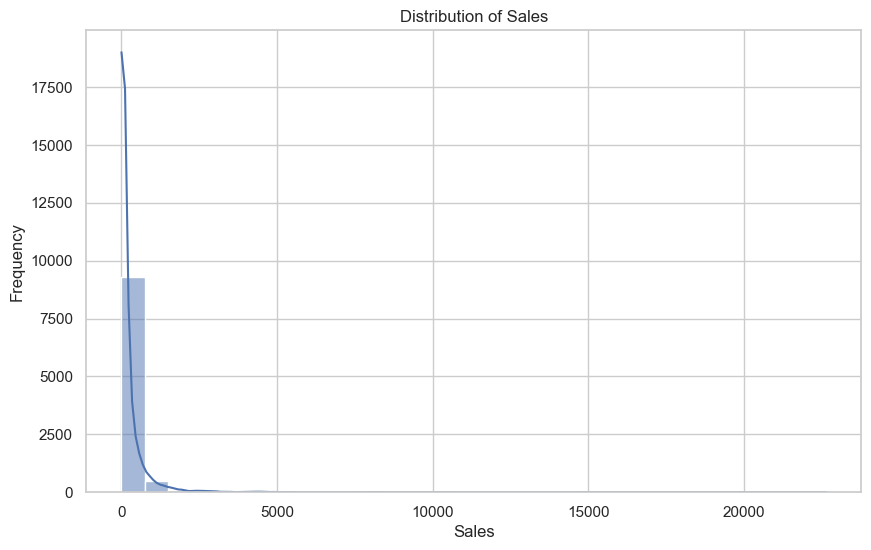

In [56]:
# 5. DATA DISTRIBUTIONS

# --- Sales Distribution ---
plt.figure()
sns.histplot(df["Sales"], bins=30, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

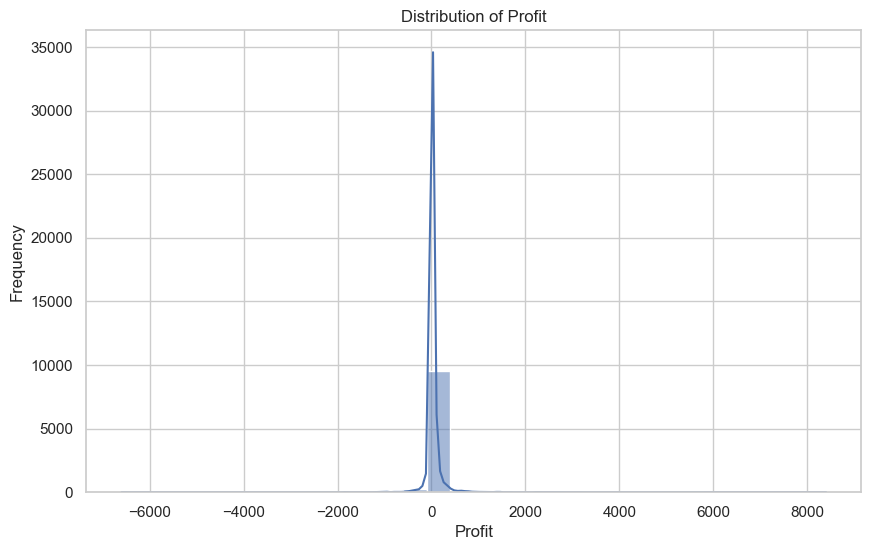

In [62]:
# --- Profit Distribution ---
plt.figure()
sns.histplot(df["Profit"], bins=30, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


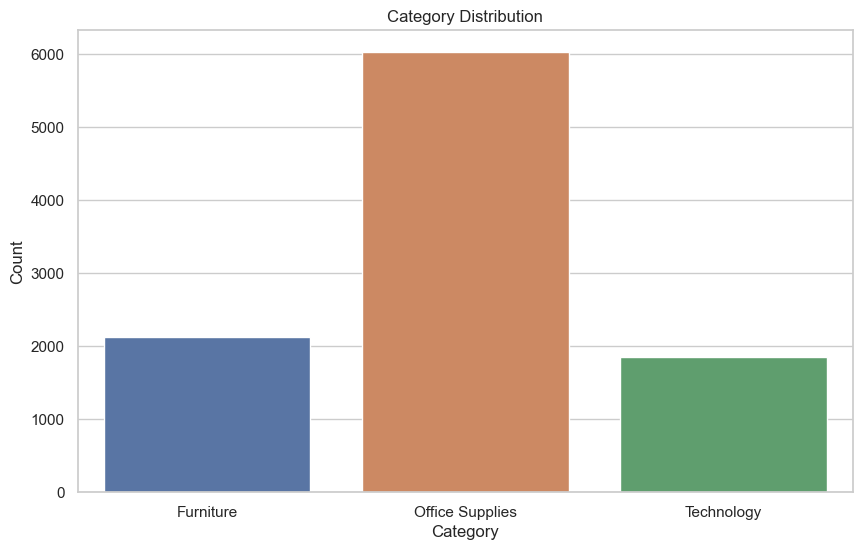

In [63]:
# --- Category Count ---
plt.figure()
sns.countplot(data=df, x="Category")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

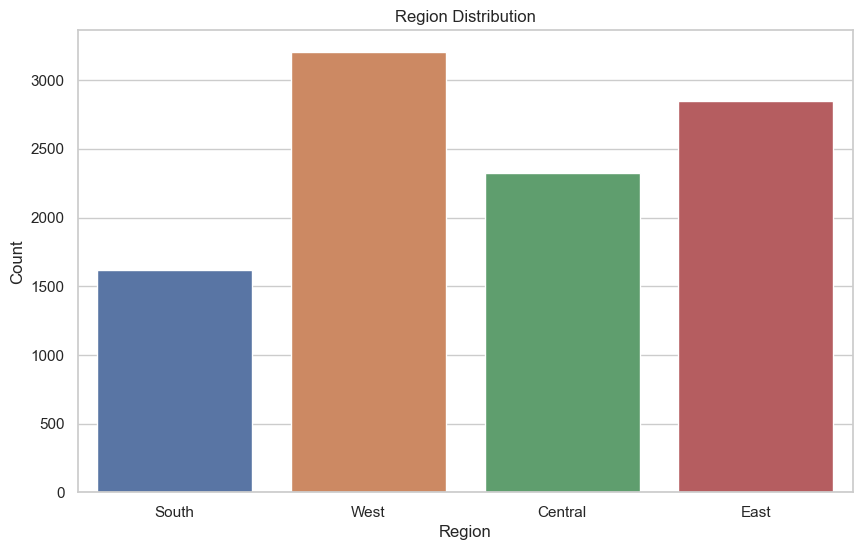

In [64]:
# --- Region Count ---
plt.figure()
sns.countplot(data=df, x="Region")
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()


In [65]:
# 6. STATISTICAL SUMMARIES

print("\n=== BASIC STATISTICS (Sales, Profit, Quantity, Discount) ===\n")
print(df[["Sales", "Profit", "Quantity", "Discount"]].describe())


=== BASIC STATISTICS (Sales, Profit, Quantity, Discount) ===

              Sales       Profit     Quantity     Discount
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     3.789574     0.156203
std      623.245101   234.260108     2.225110     0.206452
min        0.444000 -6599.978000     1.000000     0.000000
25%       17.280000     1.728750     2.000000     0.000000
50%       54.490000     8.666500     3.000000     0.200000
75%      209.940000    29.364000     5.000000     0.200000
max    22638.480000  8399.976000    14.000000     0.800000


In [81]:
print("\nMean Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Standard Deviation of Profit:", df["Profit"].std())


Mean Sales: 229.8580008304938
Median Sales: 54.489999999999995
Standard Deviation of Profit: 234.26010769095757


In [68]:
# 7. EXPLORATORY DATA ANALYSIS (EDA)

# --- Correlation Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

TypeError: corr() got an unexpected keyword argument 'numeric_only'

<Figure size 1000x600 with 0 Axes>

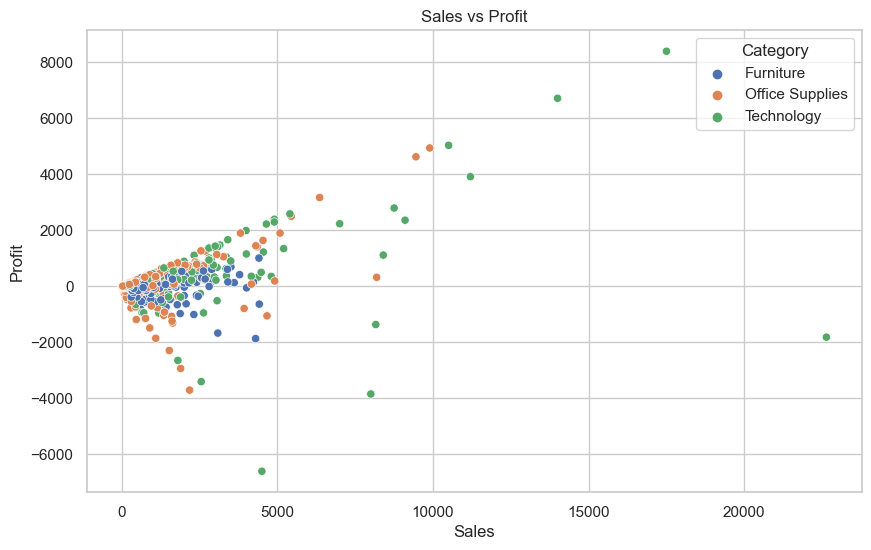

In [69]:
# --- Sales vs Profit ---
plt.figure()
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Category")
plt.title("Sales vs Profit")
plt.show()

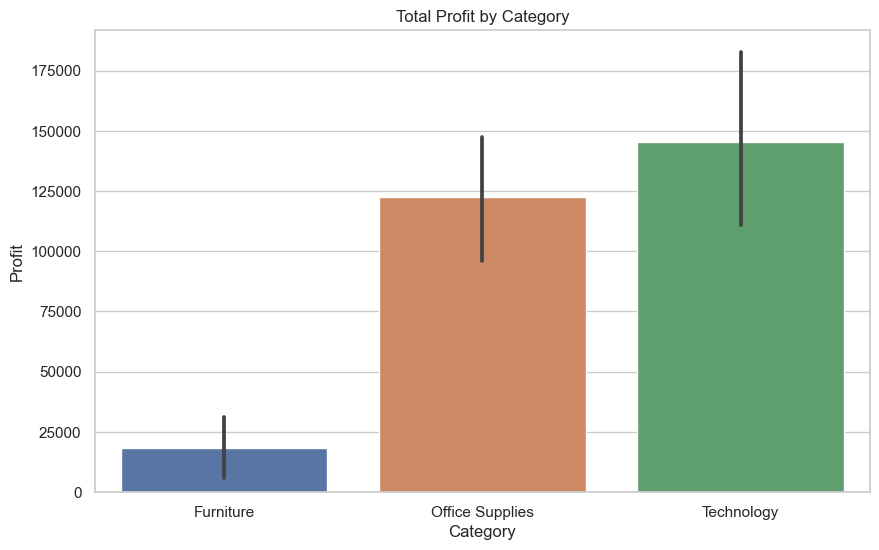

In [70]:
# --- Profit by Category ---
plt.figure()
sns.barplot(data=df, x="Category", y="Profit", estimator=np.sum)
plt.title("Total Profit by Category")
plt.show()

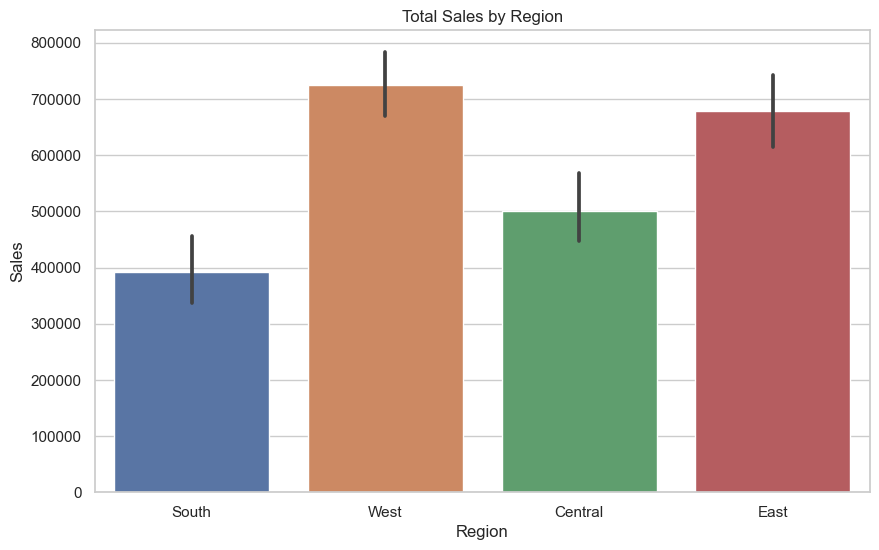

In [71]:
# --- Sales by Region ---
plt.figure()
sns.barplot(data=df, x="Region", y="Sales", estimator=np.sum)
plt.title("Total Sales by Region")
plt.show()

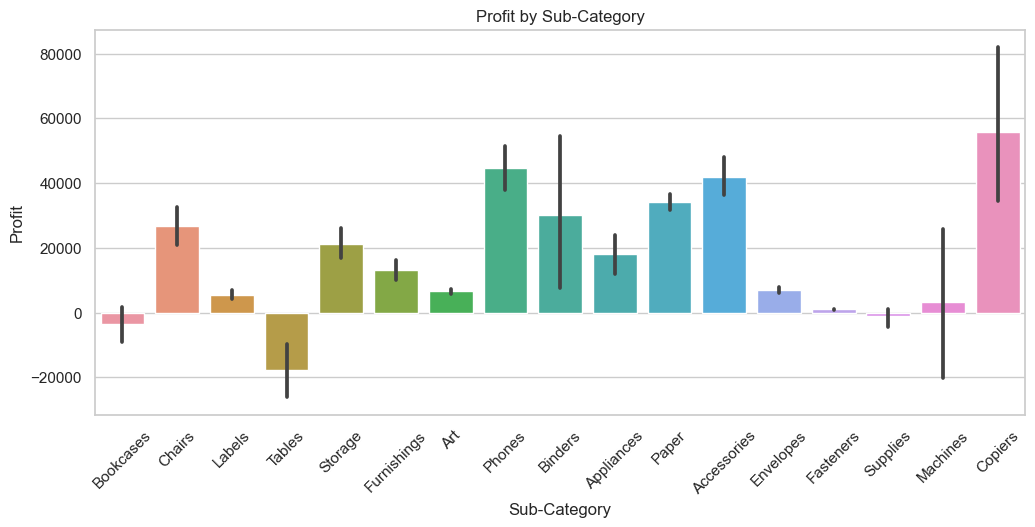

In [72]:
# --- Profit by Sub-Category ---
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x="Sub-Category", y="Profit", estimator=np.sum)
plt.title("Profit by Sub-Category")
plt.xticks(rotation=45)
plt.show()


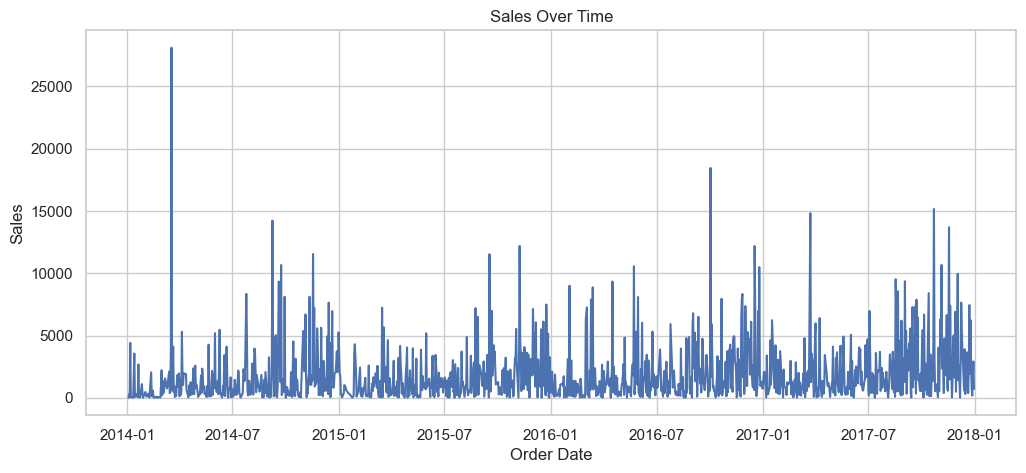

In [73]:
# --- Time Series: Sales Over Time ---
df_time = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(df_time.index, df_time.values)
plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()

In [74]:
# 8. FINAL INSIGHTS / SUMMARY REPORT

print("\n========== FINAL INSIGHTS ==========\n")

# Most profitable category
most_profitable_category = df.groupby("Category")["Profit"].sum().idxmax()
print("Most Profitable Category:", most_profitable_category)


========== FINAL INSIGHTS ==========

Most Profitable Category: Technology


In [75]:
# Least profitable sub-category
least_profitable_subcat = df.groupby("Sub-Category")["Profit"].sum().idxmin()
print("Least Profitable Sub-Category:", least_profitable_subcat)

Least Profitable Sub-Category: Tables


In [76]:
# Region with highest sales
top_region = df.groupby("Region")["Sales"].sum().idxmax()
print("Region With Highest Sales:", top_region)

Region With Highest Sales: West


In [77]:
# Month with highest sales
df["Month"] = df["Order Date"].dt.month
best_month = df.groupby("Month")["Sales"].sum().idxmax()
print("Month With Highest Sales:", best_month)

Month With Highest Sales: 11


In [78]:
print("\n---------- GENERAL OBSERVATIONS ----------")
print("1. Sales and Profit show moderate positive correlation.")
print("2. Some sub-categories have large losses (e.g., Tables).")
print("3. West and East regions show strong performance.")
print("4. Seasonal sales trends appear in time-series analysis.")
print("5. Discounts negatively impact profit in several categories.")


---------- GENERAL OBSERVATIONS ----------
1. Sales and Profit show moderate positive correlation.
2. Some sub-categories have large losses (e.g., Tables).
3. West and East regions show strong performance.
4. Seasonal sales trends appear in time-series analysis.
5. Discounts negatively impact profit in several categories.
